# Project 5 - Clustering Techniques
- I think it will be easiest to implement these thechniques one by one in a notebook so that we can work on them individually.
- can turn it into a .py if needed


## Synthetic Data Generation

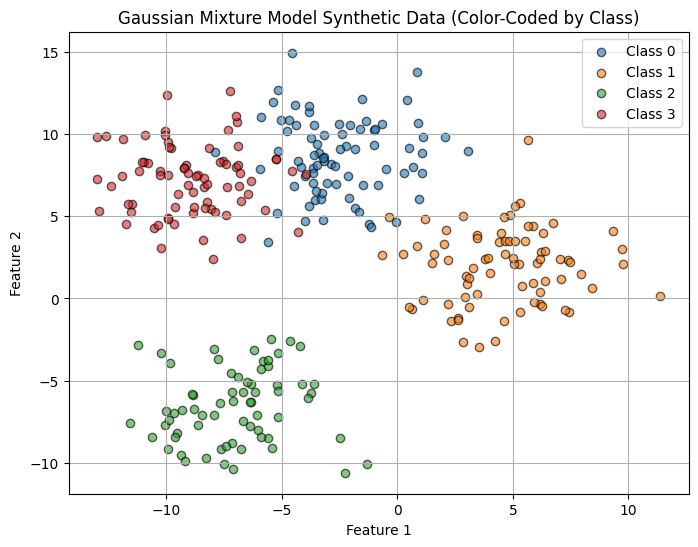

In [ ]:
# Gaussian mixture model synthetic data generator
import numpy as np
from torch import seed


def generate_gmm_data_with_noise(n_samples, n_components, n_features, n_noise, seed=42):
    np.random.seed(seed)
    # Generate random means and covariances for the GMM components
    means = np.random.rand(n_components, n_features) * 20 - 10

    covariances = np.array([4 * np.eye(n_features) for _ in range(n_components)])

    # Generate samples from the GMM
    samples = []
    labels = []
    for i in range(n_samples):
        component = np.random.choice(n_components)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)
        labels.append(component)
    for i in range(n_noise):
        noise = np.random.uniform(low=-10, high=10, size=n_features)
        samples.append(noise)
        labels.append(n_components)  # Use n_components as noise label to avoid collision
    return np.array(samples), np.array(labels)
# Example usage
if __name__ == "__main__":
    n_samples = 300
    n_components = 4
    n_features = 2
    n_noise = 0
    data, labels = generate_gmm_data_with_noise(n_samples, n_components, n_features, n_noise)
    # save data and labels to csv
    data_with_labels = np.hstack((data, labels.reshape(-1, 1)))
    np.savetxt(f"{n_components}_components.csv", data_with_labels, delimiter=",", header="Feature1,Feature2,Label", comments="")

# visualize
import matplotlib.pyplot as plt
def visualize_data(data, labels, color=True):
    unique_labels = np.unique(labels)
    n_unique = len(unique_labels)
    
    # Generate enough colors for all classes
    if n_unique <= 10:
        colors = plt.cm.tab10(np.arange(n_unique))
    else:
        colors = plt.cm.tab20(np.arange(n_unique))
    
    plt.figure(figsize=(8, 6))
    for idx, class_id in enumerate(unique_labels):
        mask = labels == class_id
        if class_id == 5:  # Noise class
            plt.scatter(data[mask, 0], data[mask, 1], alpha=0.6, label=f'Noise (Class {class_id})', 
                       color='black', marker='x', s=100)
        else:
            plt.scatter(data[mask, 0], data[mask, 1], alpha=0.6, label=f'Class {class_id}', 
                       color=colors[idx], edgecolors='k')
    plt.title("Gaussian Mixture Model Synthetic Data (Color-Coded by Class)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
    plt.show()
if __name__ == "__main__":
    visualize_data(data, labels)

## K-Means

## DBSCAN ##


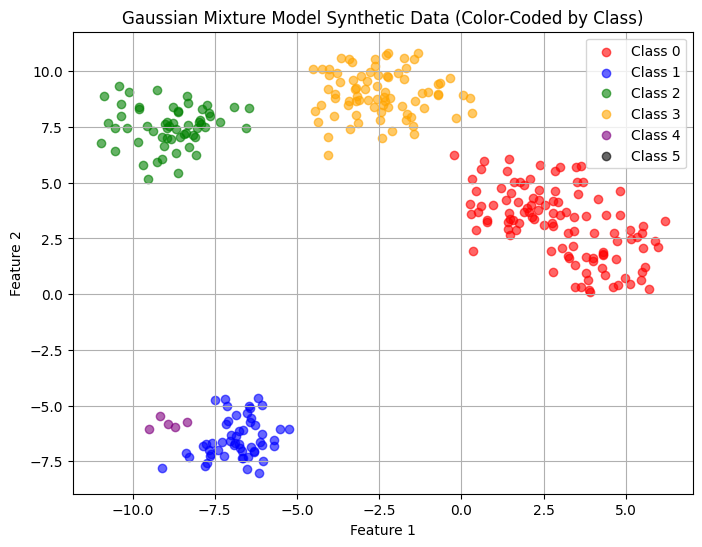

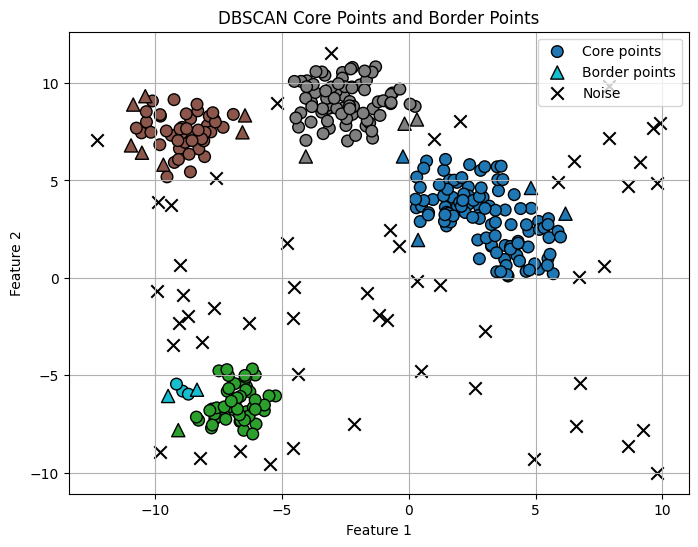

In [116]:
# DBSCAN clustering
from sklearn.cluster import DBSCAN
if __name__ == "__main__":
    # DBSCAN clustering
    dbscan = DBSCAN(eps=1, min_samples=5)
    cluster_labels = dbscan.fit_predict(data)
    visualize_data(data, cluster_labels, color=True)

    # Plot core points and border points in a separate graph
    core_indices = set(dbscan.core_sample_indices_)
    core_mask = np.array([index in core_indices for index in range(len(data))])
    border_mask = (cluster_labels != -1) & ~core_mask
    noise_mask = cluster_labels == -1

    plt.figure(figsize=(8, 6))
    plt.scatter(data[core_mask, 0], data[core_mask, 1], c=cluster_labels[core_mask], cmap="tab10", s=70, marker="o", edgecolors="k", label="Core points")
    plt.scatter(data[border_mask, 0], data[border_mask, 1], c=cluster_labels[border_mask], cmap="tab10", s=90, marker="^", edgecolors="k", label="Border points")
    plt.scatter(data[noise_mask, 0], data[noise_mask, 1], c="black", s=80, marker="x", label="Noise")
    plt.title("DBSCAN Core Points and Border Points")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid()
    plt.show()
# calculate accuracy


In [106]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score

# Treat DBSCAN noise as -1 and compute internal clustering metrics on the non-noise points.
valid_mask = cluster_labels != -1
X_eval = data[valid_mask]
y_eval = cluster_labels[valid_mask]

print(f"Total points: {len(data)}")
print(f"Clustered points: {len(X_eval)}")
print(f"Noise points: {np.sum(~valid_mask)}")
print(f"Clusters found: {len(np.unique(y_eval))}")

if len(np.unique(y_eval)) > 1:
    silhouette = silhouette_score(X_eval, y_eval)
    davies_bouldin = davies_bouldin_score(X_eval, y_eval)
    calinski_harabasz = calinski_harabasz_score(X_eval, y_eval)

    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Score: {calinski_harabasz:.4f}")
else:
    print("Silhouette Score: undefined (need at least 2 clusters)")
    print("Davies-Bouldin Index: undefined (need at least 2 clusters)")
    print("Calinski-Harabasz Score: undefined (need at least 2 clusters)")

# Optional external validation against the synthetic labels if they are available.
if "labels" in globals():
    ari = adjusted_rand_score(labels, cluster_labels)
    nmi = normalized_mutual_info_score(labels, cluster_labels)
    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Normalized Mutual Information: {nmi:.4f}")

Total points: 360
Clustered points: 306
Noise points: 54
Clusters found: 5
Silhouette Score: 0.6210
Davies-Bouldin Index: 0.5066
Calinski-Harabasz Score: 1314.0665
Adjusted Rand Index: 0.6916
Normalized Mutual Information: 0.7580


In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# Build a fixed 5-component synthetic set with class 5 reserved for noise.
def generate_five_class_synthetic_set(n_samples=300, n_components=3, n_features=2, n_noise=75, seed=42):
    np.random.seed(seed)
    means = np.random.rand(n_components, n_features) * 20 - 10
    covariances = np.array([np.eye(n_features) for _ in range(n_components)])

    samples = []
    labels = []
    for _ in range(n_samples):
        component = np.random.choice(n_components)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)
        labels.append(component)

    for _ in range(n_noise):
        noise = np.random.uniform(low=-10, high=10, size=n_features)
        samples.append(noise)
        labels.append(5)

    return np.array(samples), np.array(labels)

five_class_data, five_class_labels = generate_five_class_synthetic_set()

def plot_dbscan_with_controls(eps, min_samples):
    dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan_model.fit_predict(five_class_data)

    core_indices = set(dbscan_model.core_sample_indices_)
    core_mask = np.array([idx in core_indices for idx in range(len(five_class_data))])
    border_mask = (dbscan_labels != -1) & ~core_mask
    noise_mask = dbscan_labels == -1

    unique_cluster_labels = sorted(label for label in np.unique(dbscan_labels) if label != -1)
    palette = plt.cm.tab10(np.arange(max(len(unique_cluster_labels), 1)))
    cluster_color_map = {cluster_label: palette[i % len(palette)] for i, cluster_label in enumerate(unique_cluster_labels)}

    with output:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 6))

        for cluster_label in unique_cluster_labels:
            cluster_mask = dbscan_labels == cluster_label
            ax.scatter(
                five_class_data[cluster_mask, 0],
                five_class_data[cluster_mask, 1],
                s=55,
                color=cluster_color_map[cluster_label],
                alpha=0.7,
                label=f'Cluster {cluster_label}'
            )

        if np.any(core_mask):
            ax.scatter(
                five_class_data[core_mask, 0],
                five_class_data[core_mask, 1],
                s=95,
                facecolors='none',
                edgecolors='black',
                linewidths=1.0,
                marker='o',
                label='Core points'
            )

        if np.any(border_mask):
            ax.scatter(
                five_class_data[border_mask, 0],
                five_class_data[border_mask, 1],
                s=85,
                facecolors='none',
                edgecolors='black',
                linewidths=1.0,
                marker='^',
                label='Border points'
            )

        if np.any(noise_mask):
            ax.scatter(
                five_class_data[noise_mask, 0],
                five_class_data[noise_mask, 1],
                s=80,
                color='black',
                marker='x',
                label='Noise'
            )

        n_clusters = len(unique_cluster_labels)
        n_noise_points = int(np.sum(noise_mask))
        ax.set_title(f'DBSCAN on 5-Class Synthetic Set | eps={eps:.2f}, min_samples={min_samples} | clusters={n_clusters}, noise={n_noise_points}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.grid(True)
        ax.legend(loc='best')
        plt.show()

    print(f'Clusters found: {n_clusters}')
    print(f'Core points: {int(np.sum(core_mask))}')
    print(f'Border points: {int(np.sum(border_mask))}')
    print(f'Noise points: {n_noise_points}')

output = widgets.Output()
eps_slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='eps', continuous_update=False)
min_samples_slider = widgets.IntSlider(value=5, min=1, max=25, step=1, description='min_samples', continuous_update=False)

controls = widgets.VBox([
    eps_slider,
    min_samples_slider
])

ui = widgets.HBox([controls, output])
display(ui)
widgets.interactive_output(plot_dbscan_with_controls, {'eps': eps_slider, 'min_samples': min_samples_slider})

Output()

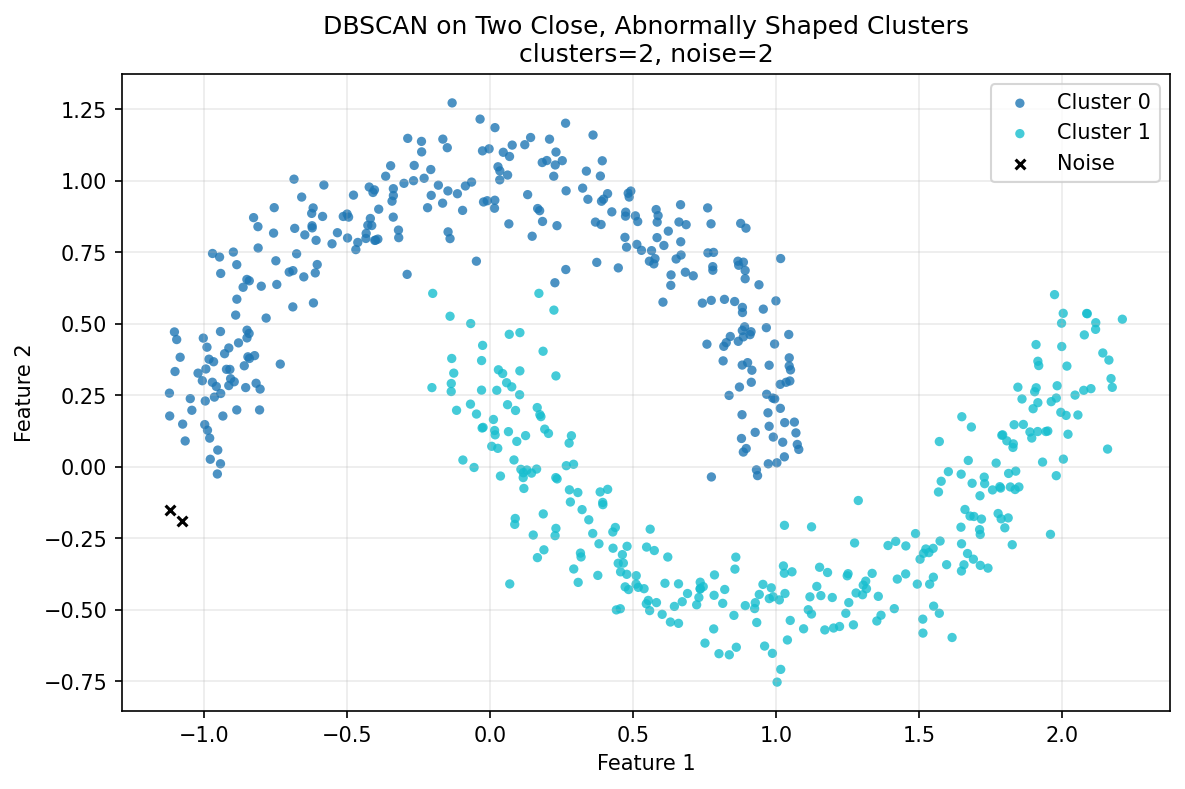

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Two close, abnormally shaped clusters with light noise.
X_two, y_two = make_moons(n_samples=600, noise = 0.10, random_state=42)



model = DBSCAN(eps=0.18, min_samples=8)
labels_dbscan = model.fit_predict(X_two)
unique_labels = sorted(label for label in np.unique(labels_dbscan) if label != -1)
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
for idx, cluster_label in enumerate(unique_labels):
    cluster_mask = labels_dbscan == cluster_label
    ax.scatter(
        X_two[cluster_mask, 0],
        X_two[cluster_mask, 1],
        s=20,
        color=palette[idx % len(palette)],
        alpha=0.8,
        edgecolors='none',
        label=f'Cluster {cluster_label}',
    )

noise_mask = labels_dbscan == -1
if np.any(noise_mask):
    ax.scatter(
        X_two[noise_mask, 0],
        X_two[noise_mask, 1],
        s=22,
        color='black',
        marker='x',
        label='Noise',
    )

ax.set_title(f"DBSCAN on Two Close, Abnormally Shaped Clusters\nclusters={len(unique_labels)}, noise={int(np.sum(noise_mask))}")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

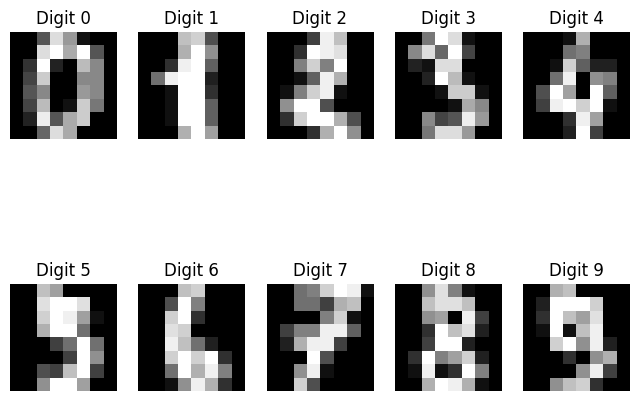

In [44]:
from sklearn.datasets import load_digits
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

# visualize digits data
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_digits[y_digits == i][0].reshape(8, 8), cmap='gray')
    plt.title(f'Digit {i}')
    plt.axis('off')

plt.show()

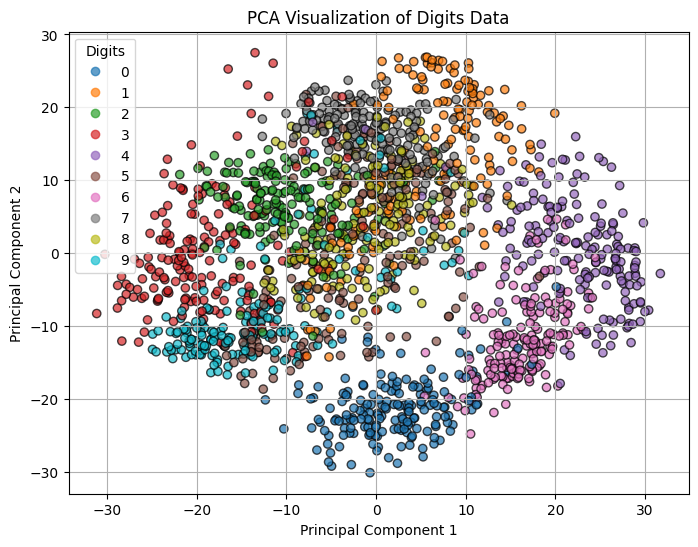

In [46]:
# 3-D PCA visualization of digits data
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_digits)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap='tab10', alpha=0.7, edgecolors='k')
plt.title("PCA Visualization of Digits Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(*scatter.legend_elements(), title="Digits")
plt.grid()
plt.show()



Euclidean eps grid: [2.5498, 3.2364, 3.3997, 3.8295, 4.2497, 4.7528, 5.0996, 5.7718, 5.9496]

Mahalanobis eps grid: [3.7685, 5.0022, 5.0247, 5.7216, 6.2808, 6.8704, 7.537 , 8.0742, 8.7932]

Cosine eps grid: [0.1088, 0.114 , 0.1499, 0.152 , 0.19  , 0.228 , 0.2419, 0.266 , 0.3254]
DBSCAN on Digits using all raw features
     Metric      eps  Clusters  Clustered Points  Noise Points  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Score  Adjusted Rand Index  Normalized Mutual Information
  Euclidean 2.549808         2                44          1753          0.673613              0.440076                83.667485             0.001692                       0.047972
  Euclidean 3.236380        14               323          1474          0.341799              0.948904                65.063634             0.029284                       0.281316
  Euclidean 3.399744        21               444          1353          0.265393              1.099874                53.534498            

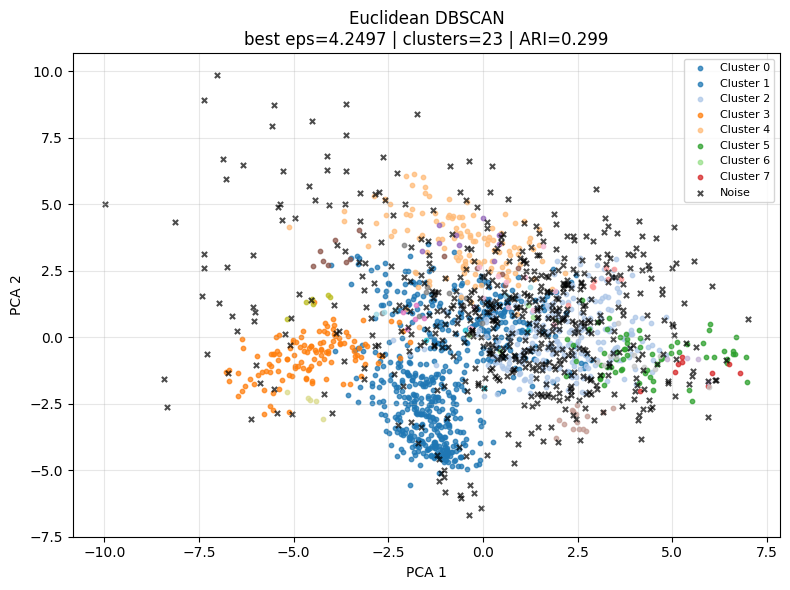

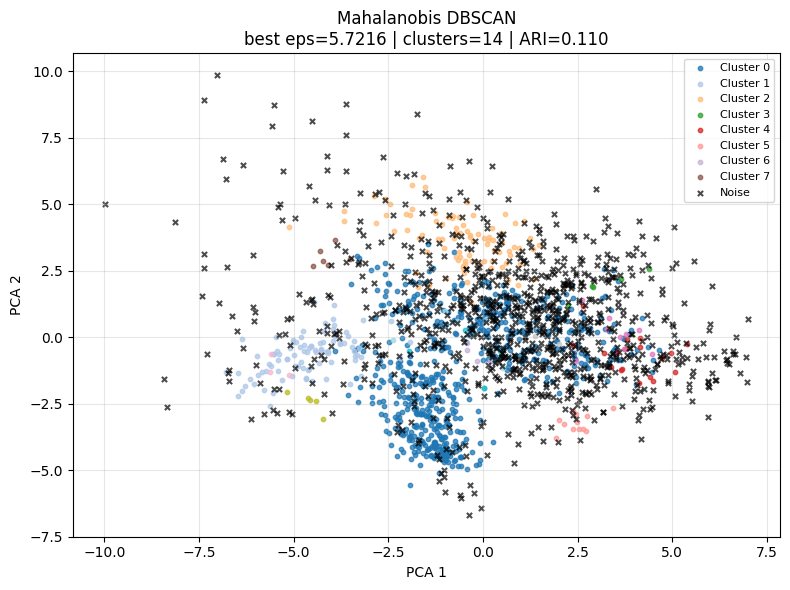

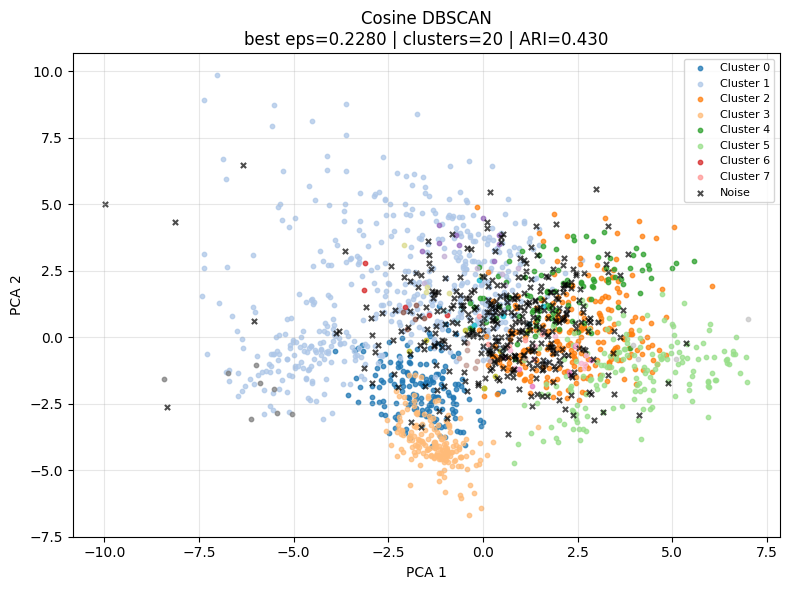

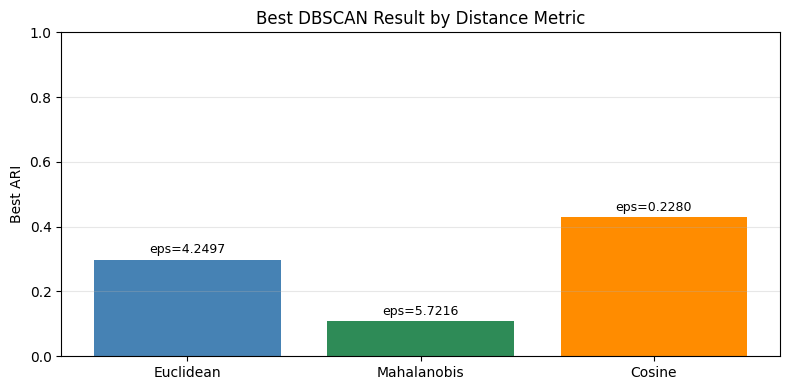

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

# Load digits and keep the full raw feature space for clustering
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# Cluster on all original features; use 2D PCA only for visualization
X_cluster = X_scaled
pca_2d = PCA(n_components=2, random_state=42)
X_vis = pca_2d.fit_transform(X_scaled)

# Mahalanobis metric needs the inverse covariance matrix in feature space
covariance = np.cov(X_cluster, rowvar=False)
vi_matrix = np.linalg.pinv(covariance)


def build_eps_grid(features, metric, metric_params=None, n_neighbors=5, percentiles=(10, 30, 50, 70, 90)):
    """Estimate a fair eps grid from k-nearest-neighbor distances for a given metric."""
    neighbor_model = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric=metric,
        metric_params=metric_params,
    )
    neighbor_model.fit(features)
    distances, _ = neighbor_model.kneighbors(features)
    k_distances = distances[:, -1]
    center = float(np.median(k_distances))
    candidate_values = np.percentile(k_distances, percentiles)
    candidate_values = np.unique(np.clip(candidate_values, 1e-6, None))

    if center > 0:
        scaled = np.unique(np.clip(center * np.array([0.6, 0.8, 1.0, 1.2, 1.4]), 1e-6, None))
        candidate_values = np.unique(np.concatenate([candidate_values, scaled]))

    return np.sort(candidate_values)

metric_specs = {
    "Euclidean": {
        "metric": "euclidean",
        "metric_params": None,
    },
    "Mahalanobis": {
        "metric": "mahalanobis",
        "metric_params": {"VI": vi_matrix},
    },
    "Cosine": {
        "metric": "cosine",
        "metric_params": None,
    },
}

comparison_rows = []
best_results = {}

for metric_name, spec in metric_specs.items():
    eps_values = build_eps_grid(X_cluster, spec["metric"], spec["metric_params"])
    best_row = None
    metric_rows = []

    print(f"\n{metric_name} eps grid: {np.array2string(eps_values, precision=4, separator=', ')}")

    for eps in eps_values:
        dbscan_model = DBSCAN(
            eps=float(eps),
            min_samples=5,
            metric=spec["metric"],
            metric_params=spec["metric_params"],
        )
        predicted_labels = dbscan_model.fit_predict(X_cluster)

        valid_mask = predicted_labels != -1
        n_clusters = len(set(predicted_labels)) - (1 if -1 in predicted_labels else 0)
        clustered_points = int(np.sum(valid_mask))
        noise_points = int(np.sum(~valid_mask))

        row = {
            "Metric": metric_name,
            "eps": float(eps),
            "Clusters": n_clusters,
            "Clustered Points": clustered_points,
            "Noise Points": noise_points,
            "Silhouette Score": np.nan,
            "Davies-Bouldin Index": np.nan,
            "Calinski-Harabasz Score": np.nan,
            "Adjusted Rand Index": np.nan,
            "Normalized Mutual Information": np.nan,
            "Predicted Labels": predicted_labels,
        }

        if n_clusters > 1 and clustered_points > 1 and len(np.unique(predicted_labels[valid_mask])) > 1:
            X_eval = X_cluster[valid_mask]
            y_eval = predicted_labels[valid_mask]
            row["Silhouette Score"] = silhouette_score(X_eval, y_eval)
            row["Davies-Bouldin Index"] = davies_bouldin_score(X_eval, y_eval)
            row["Calinski-Harabasz Score"] = calinski_harabasz_score(X_eval, y_eval)
            row["Adjusted Rand Index"] = adjusted_rand_score(y_digits, predicted_labels)
            row["Normalized Mutual Information"] = normalized_mutual_info_score(y_digits, predicted_labels)

        metric_rows.append(row)

        if best_row is None:
            if not np.isnan(row["Adjusted Rand Index"]):
                best_row = row
        else:
            current_ari = row["Adjusted Rand Index"]
            best_ari = best_row["Adjusted Rand Index"]
            if not np.isnan(current_ari) and (np.isnan(best_ari) or current_ari > best_ari):
                best_row = row

    comparison_rows.append(pd.DataFrame(metric_rows).drop(columns=["Predicted Labels"]))
    if best_row is not None:
        best_results[metric_name] = best_row

results_table = pd.concat(comparison_rows, ignore_index=True)
print("DBSCAN on Digits using all raw features")
print(results_table.to_string(index=False))


def plot_best_metric(metric_name, best_row):
    """Plot the best clustering for a single metric in its own figure."""
    predicted_labels = best_row["Predicted Labels"]
    unique_cluster_labels = sorted(label for label in np.unique(predicted_labels) if label != -1)
    color_values = plt.cm.tab20(np.linspace(0, 1, max(len(unique_cluster_labels), 1)))

    fig, ax = plt.subplots(figsize=(8, 6))

    for idx, cluster_label in enumerate(unique_cluster_labels):
        cluster_mask = predicted_labels == cluster_label
        ax.scatter(
            X_vis[cluster_mask, 0],
            X_vis[cluster_mask, 1],
            s=10,
            color=color_values[idx % len(color_values)],
            alpha=0.75,
            label=f'Cluster {cluster_label}' if idx < 8 else None,
        )

    noise_mask = predicted_labels == -1
    if np.any(noise_mask):
        ax.scatter(
            X_vis[noise_mask, 0],
            X_vis[noise_mask, 1],
            s=14,
            color='black',
            marker='x',
            alpha=0.7,
            label='Noise',
        )

    ax.set_title(
        f"{metric_name} DBSCAN\n"
        f"best eps={best_row['eps']:.4f} | clusters={best_row['Clusters']} | ARI={best_row['Adjusted Rand Index']:.3f}"
    )
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()


for metric_name in metric_specs.keys():
    best_row = best_results.get(metric_name)
    if best_row is None:
        print(f"{metric_name}: no valid clustering found")
    else:
        plot_best_metric(metric_name, best_row)

# Small summary graph of the best ARI achieved by each metric
best_summary = pd.DataFrame([
    {
        "Metric": metric_name,
        "Best eps": best_results[metric_name]["eps"],
        "Best ARI": best_results[metric_name]["Adjusted Rand Index"],
    }
    for metric_name in best_results
])

fig, ax = plt.subplots(figsize=(8, 4))
bar_positions = np.arange(len(best_summary))
ax.bar(bar_positions, best_summary["Best ARI"], color=['steelblue', 'seagreen', 'darkorange'])
ax.set_xticks(bar_positions)
ax.set_xticklabels(best_summary["Metric"])
ax.set_ylabel("Best ARI")
ax.set_title("Best DBSCAN Result by Distance Metric")
ax.set_ylim(0, max(1.0, float(best_summary["Best ARI"].max()) + 0.1))
ax.grid(axis='y', alpha=0.3)

for i, row in best_summary.iterrows():
    ax.text(i, row["Best ARI"] + 0.01, f"eps={row['Best eps']:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

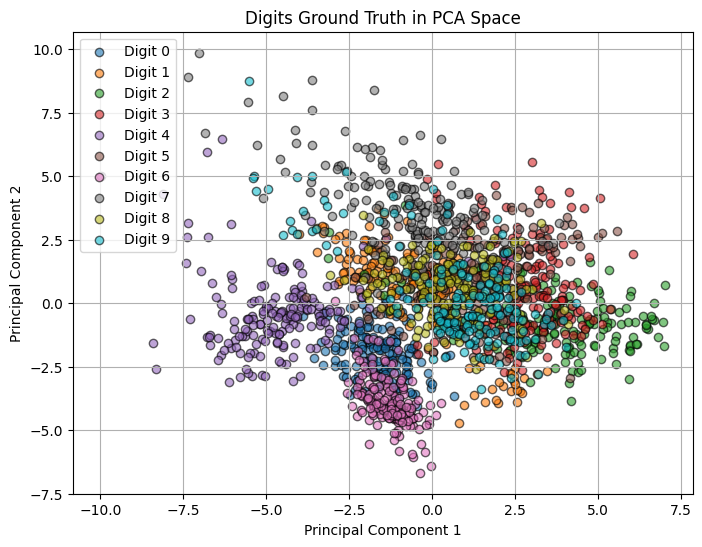

In [54]:
# plot ground truth labels for digits in PCA space
plt.figure(figsize=(8, 6))
unique_labels = np.unique(y_digits)
colors = plt.cm.tab10(np.arange(len(unique_labels)))
for idx, label in enumerate(unique_labels):
    mask = y_digits == label
    plt.scatter(X_vis[mask, 0], X_vis[mask, 1], color=colors[idx], alpha=0.6, edgecolors='k', label=f'Digit {label}')
plt.title("Digits Ground Truth in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# calculate variance for each digit class in PCA space
pca_full = PCA(n_components=X_scaled.shape[1], random_state=42)
X_full_pca = pca_full.fit_transform(X_scaled)
digit_variances = {}
for digit in np.unique(y_digits):
    digit_mask = y_digits == digit
    digit_variances[digit] = np.var(X_full_pca[digit_mask], axis=0)
for digit, variances in digit_variances.items():
    print(f"Digit {digit} variance in PCA space: {variances[:5]}...")
    


Digit 0 variance in PCA space: [0.66386014 1.03138773 1.05514917 0.86339088 0.30703709]...
Digit 1 variance in PCA space: [2.44009182 3.18611473 4.56742015 4.12964077 4.44610077]...
Digit 2 variance in PCA space: [3.92300848 1.3324037  1.08959091 2.77475387 2.77817244]...
Digit 3 variance in PCA space: [1.4419068  3.18215481 1.68009559 0.86646886 0.91117834]...
Digit 4 variance in PCA space: [2.52160945 2.33536178 1.2903868  2.823683   5.88231055]...
Digit 5 variance in PCA space: [2.65641099 2.21609712 3.23137736 4.10207465 0.38409509]...
Digit 6 variance in PCA space: [0.34290009 0.94127127 1.44521951 2.13040504 1.30024771]...
Digit 7 variance in PCA space: [3.50923313 2.72572814 1.10038245 0.75805348 7.27750059]...
Digit 8 variance in PCA space: [1.7672859  1.27665982 1.70828187 2.02200717 0.73505001]...
Digit 9 variance in PCA space: [4.00739143 3.80656985 1.93530755 1.49994554 1.71491975]...


In [59]:
# calculate single value representation of variance for each digit class (e.g. mean variance across all PCA components)
digit_mean_variances = {digit: np.mean(variances) for digit, variances in digit_variances.items()}
for digit, mean_var in digit_mean_variances.items():
    print(f"Digit {digit} mean variance in PCA space: {mean_var:.4f}")

# make a table of digit vs mean variance
variance_table = pd.DataFrame({
    "Digit": list(digit_mean_variances.keys()),
    "Mean Variance": list(digit_mean_variances.values())
})
print(variance_table.to_string(index=False))

Digit 0 mean variance in PCA space: 0.2635
Digit 1 mean variance in PCA space: 0.8281
Digit 2 mean variance in PCA space: 0.8859
Digit 3 mean variance in PCA space: 0.4846
Digit 4 mean variance in PCA space: 1.2197
Digit 5 mean variance in PCA space: 0.5878
Digit 6 mean variance in PCA space: 0.4673
Digit 7 mean variance in PCA space: 0.7238
Digit 8 mean variance in PCA space: 0.5632
Digit 9 mean variance in PCA space: 0.5704
 Digit  Mean Variance
     0       0.263459
     1       0.828102
     2       0.885921
     3       0.484569
     4       1.219693
     5       0.587800
     6       0.467316
     7       0.723849
     8       0.563177
     9       0.570350


# Mean Shift

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Mean Shift on the digits dataset with a single static bandwidth.
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# Static bandwidth — change this value if you want to try a different kernel size.
BANDWIDTH = 4.3667

model = MeanShift(bandwidth=BANDWIDTH, bin_seeding=False)
labels = model.fit_predict(X_scaled)
centers = model.cluster_centers_

# 2D PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_scaled)
center_vis = pca.transform(centers)

unique_labels = np.unique(labels)
colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))

plt.figure(figsize=(8, 6), dpi=150)
for idx, label in enumerate(unique_labels):
    mask = labels == label
    plt.scatter(
        X_vis[mask, 0],
        X_vis[mask, 1],
        s=14,
        alpha=0.75,
        color=colors[idx % len(colors)],
    )

plt.scatter(
    center_vis[:, 0],
    center_vis[:, 1],
    s=120,
    marker='X',
    color='black',
    label='Centers',
)

ari = adjusted_rand_score(y_digits, labels)

plt.title(
    f"Mean Shift on Digits Dataset\n"
    f"bandwidth={BANDWIDTH:.3f}, clusters={len(unique_labels)}, ARI={ari:.3f}"
)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Bandwidth: {BANDWIDTH:.4f}")
print(f"Clusters found: {len(unique_labels)}")
print(f"Adjusted Rand Index: {ari:.4f}")

KeyboardInterrupt: 

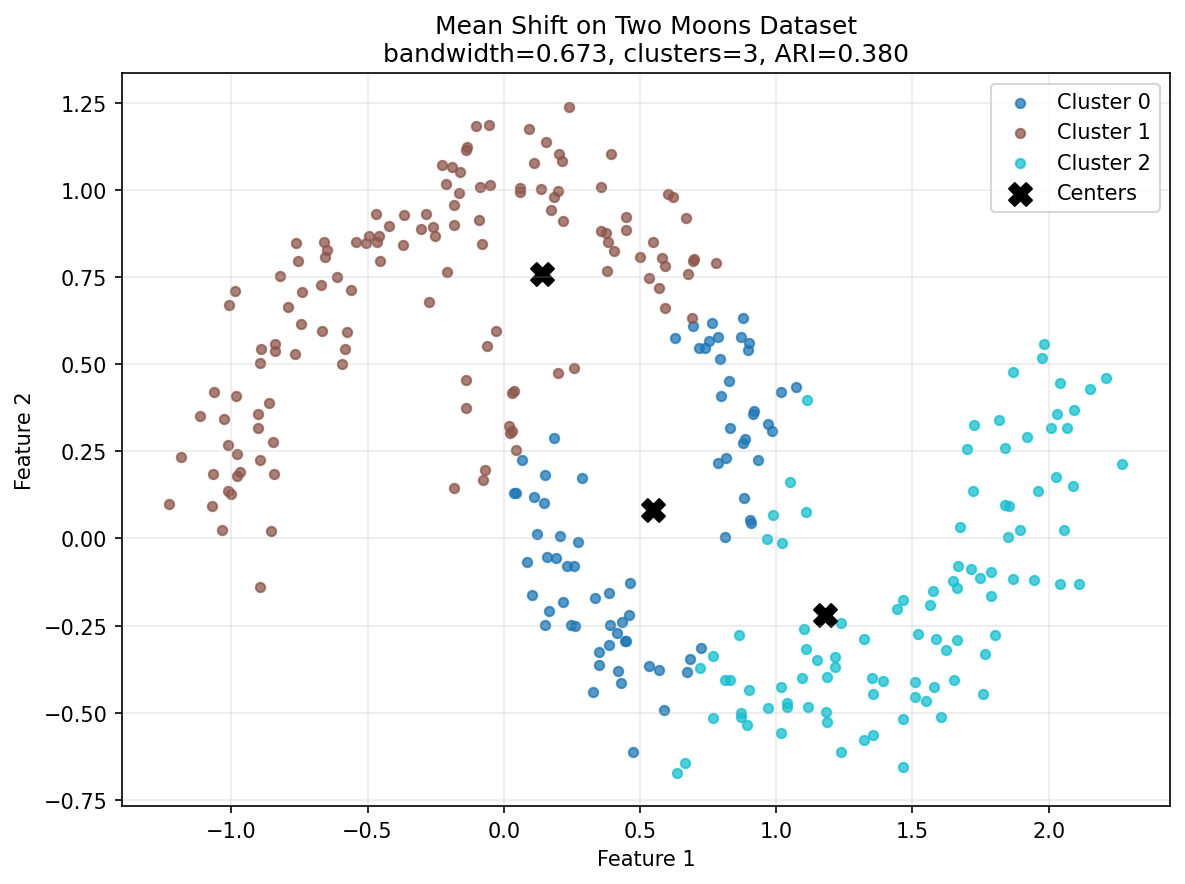

Bandwidth: 0.6728
Clusters found: 3
Adjusted Rand Index: 0.3800


In [76]:
# Mean Shift on two moons with a single static bandwidth
from sklearn.datasets import make_moons
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import numpy as np

X_moons, y_moons = make_moons(n_samples=300, noise=0.10, random_state=42)

# Estimate a bandwidth once and use it as a static value (changeable)
base_bandwidth_moons = estimate_bandwidth(X_moons, quantile=0.2, n_samples=200, random_state=42)
if base_bandwidth_moons <= 0:
    BANDWIDTH_MOONS = 0.3
else:
    BANDWIDTH_MOONS = float(base_bandwidth_moons)

model = MeanShift(bandwidth=BANDWIDTH_MOONS, bin_seeding=False)
labels = model.fit_predict(X_moons)
centers = model.cluster_centers_

ari = adjusted_rand_score(y_moons, labels)
unique_labels_moons = np.unique(labels)

plt.figure(figsize=(8, 6), dpi=150)
colors_moons = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels_moons), 1)))
for idx, label in enumerate(unique_labels_moons):
    mask = labels == label
    plt.scatter(
        X_moons[mask, 0],
        X_moons[mask, 1],
        s=20,
        alpha=0.75,
        color=colors_moons[idx % len(colors_moons)],
        label=f'Cluster {label}'
    )

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=120,
    marker='X',
    color='black',
    label='Centers'
)

plt.title(f"Mean Shift on Two Moons Dataset\nbandwidth={BANDWIDTH_MOONS:.3f}, clusters={len(unique_labels_moons)}, ARI={ari:.3f}")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(loc='best')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Bandwidth: {BANDWIDTH_MOONS:.4f}")
print(f"Clusters found: {len(unique_labels_moons)}")
print(f"Adjusted Rand Index: {ari:.4f}")